In [1]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load the data

In [ ]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [3]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [4]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    
    # ***************************************************
    e = y - tx.dot(w)
    return 1/2 * np.mean(e**2)
    # ***************************************************
    # raise NotImplementedError

# 2. Grid Search

Fill in the function `grid_search()` below:

In [5]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss for each combination of w0 and w1.
    for i, w0 in enumerate(grid_w0):
        for j, w1 in enumerate(grid_w1):
            w = np.array([w0, w1])
            losses[i, j] = compute_loss(y, tx, w)

    # ***************************************************
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=42.42448314678248, w0*=66.66666666666669, w1*=16.666666666666686, execution time=0.003 seconds


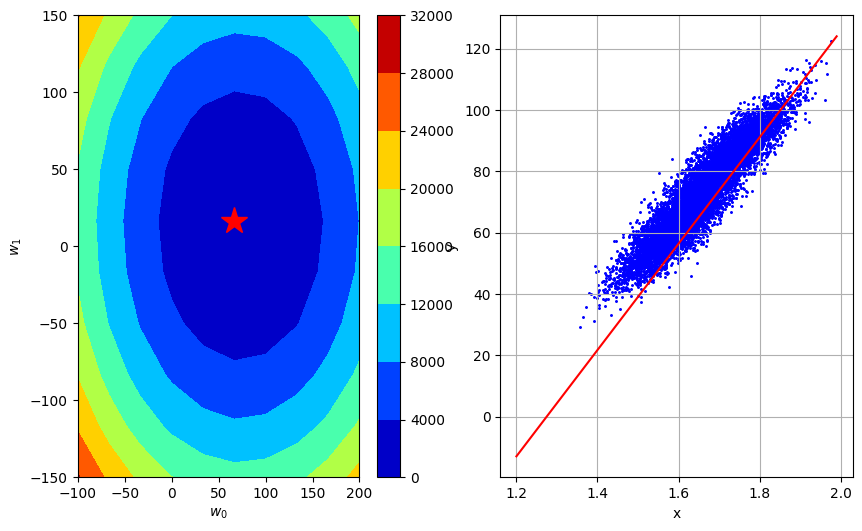

In [ ]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=10)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [7]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    e = y - tx.dot(w)
    gradient = -np.transpose(tx).dot(e)/len(y)
    # ***************************************************
    return gradient

Please fill in the functions `gradient_descent` below:

In [8]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute gradient and loss
        gradient = compute_gradient(y, tx, w)
        loss = compute_loss(y, tx, w)
        # ***************************************************
        # raise NotImplementedError
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by gradient
        w = w - gamma*gradient
        # ***************************************************
        #raise NotImplementedError

        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [27]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1

# Initialization
w_initial = np.array([-1000, 1000])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=1062606.4462798766, w0=-892.670607799789, w1=901.3479712434988
GD iter. 1/49: loss=860714.1448053943, w0=-796.0741548195997, w1=812.5611453626477
GD iter. 2/49: loss=697181.3806110647, w0=-709.1373471374292, w1=732.6530020698816
GD iter. 3/49: loss=564719.8416136572, w0=-630.8942202234756, w1=660.7356731063923
GD iter. 4/49: loss=457425.9950257573, w0=-560.4754060009176, w1=596.010077039252
GD iter. 5/49: loss=370517.9792895586, w0=-497.0984732006152, w1=537.7570405788256
GD iter. 6/49: loss=300122.4865432374, w0=-440.05923368034325, w1=485.3293077644419
GD iter. 7/49: loss=243102.13741871744, w0=-388.7239181120984, w1=438.14434823149656
GD iter. 8/49: loss=196915.65462785616, w0=-342.522134100678, w1=395.67788465184583
GD iter. 9/49: loss=159504.60356725854, w0=-300.94052849039963, w1=357.4580674301601
GD iter. 10/49: loss=129201.65220817446, w0=-263.51708344114917, w1=323.060231930643
GD iter. 11/49: loss=104656.2616073164, w0=-229.83598289682374, w1=292.102179981

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

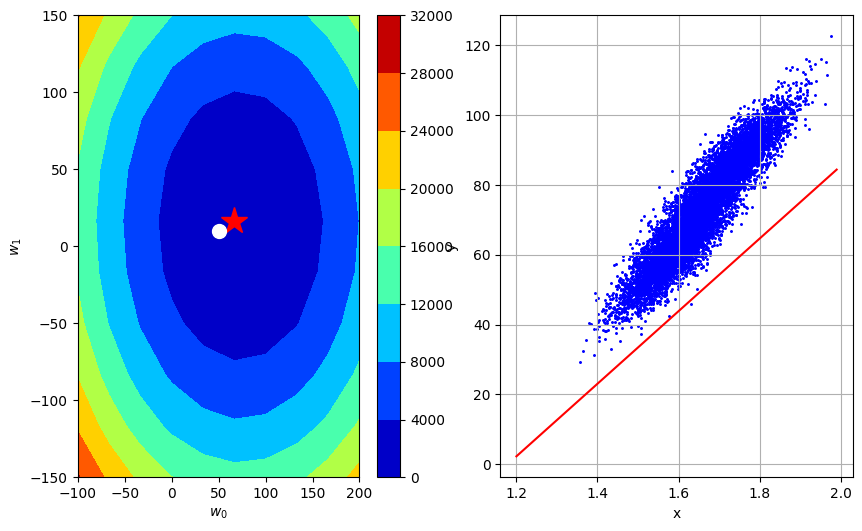

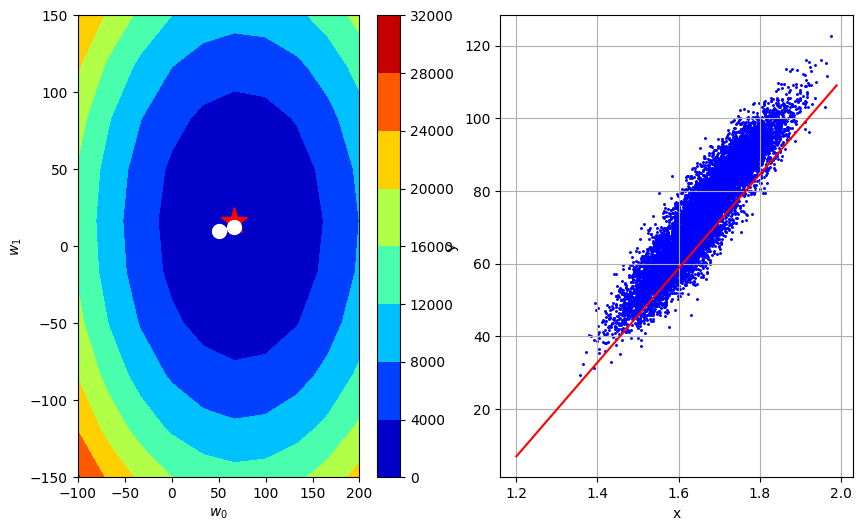

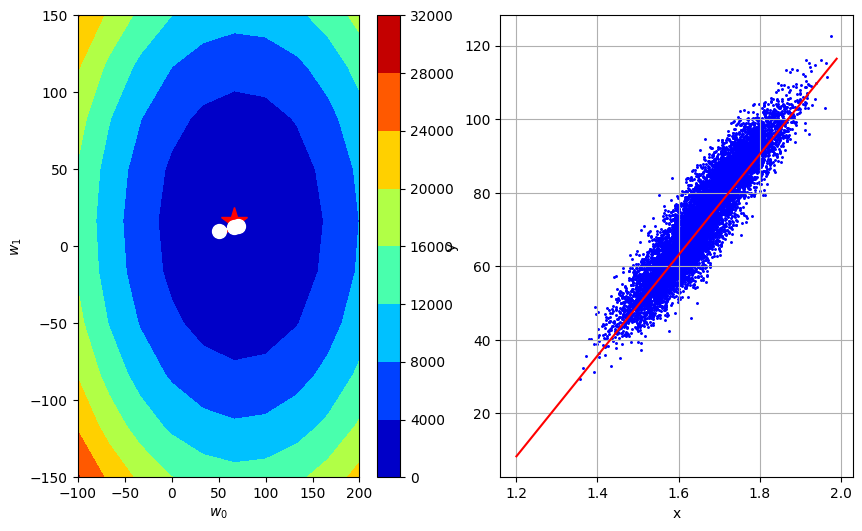

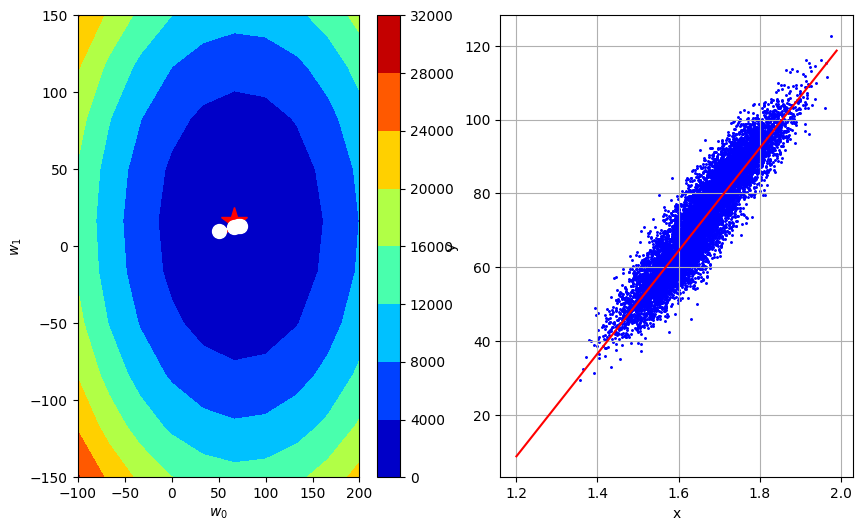

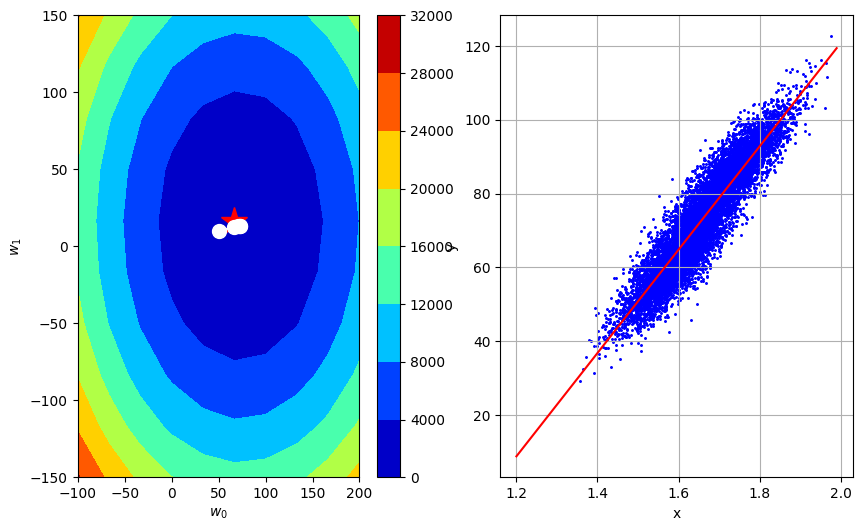

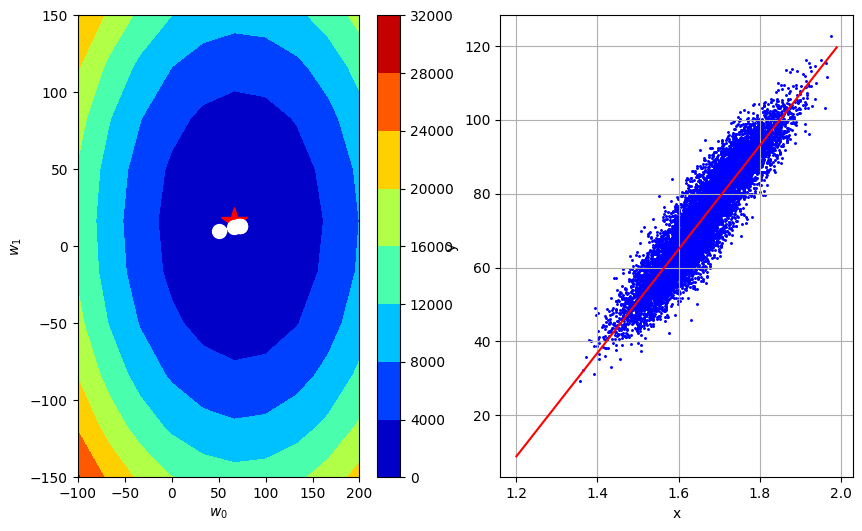

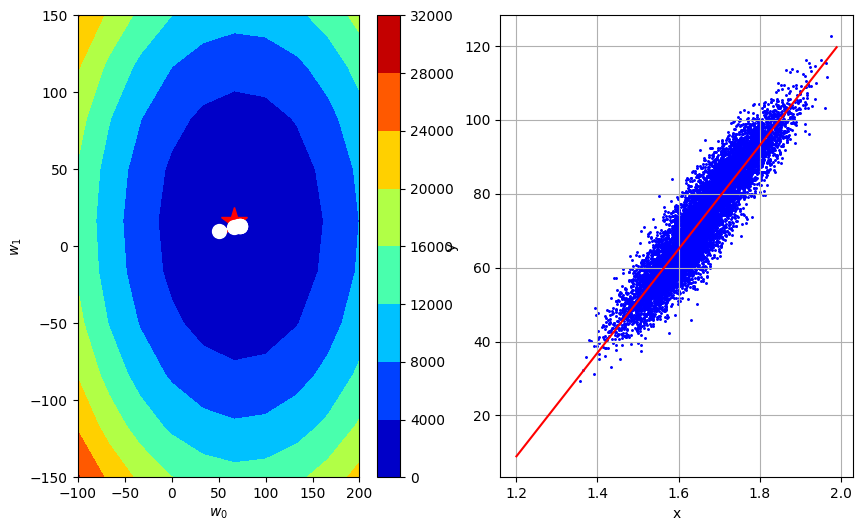

In [18]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 4. Stochastic gradient descent

In [36]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: implement stochastic gradient computation. It's the same as the usual gradient.
    e = y - tx.dot(w)
    # ***************************************************
    return -tx.T.dot(e)/len(y)


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic gradient descent.
        for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size):
            stoch_gradient = compute_stoch_gradient(minibatch_y, minibatch_tx, w)
            w = w - gamma*stoch_gradient
            loss = compute_loss(y, tx, w)
            # Store values
            ws.append(w)
            losses.append(loss)
        # ***************************************************

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [37]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=2279.0461235129364, w0=7.031424745540047, w1=1.7920296615770113
SGD iter. 1/49: loss=2057.058740650446, w0=11.646352330277779, w1=-3.340598475348515
SGD iter. 2/49: loss=1919.2772507609484, w0=15.461830763247628, w1=-8.043111467201264
SGD iter. 3/49: loss=1827.51451072606, w0=18.416665773555117, w1=-11.273953849836852
SGD iter. 4/49: loss=1508.7723205670482, w0=24.420668320121454, w1=-10.977964068164384
SGD iter. 5/49: loss=1149.810391684264, w0=30.44718338969334, w1=-7.329083731789234
SGD iter. 6/49: loss=1036.8836760870877, w0=33.76914236280048, w1=-8.447151702432018
SGD iter. 7/49: loss=1013.175321708853, w0=35.6015936133306, w1=-10.496676957762023
SGD iter. 8/49: loss=1009.0403855329348, w0=36.28239925988684, w1=-11.368953115306939
SGD iter. 9/49: loss=935.021493029982, w0=39.02246748890529, w1=-12.302812962496311
SGD iter. 10/49: loss=879.1867438442692, w0=41.31910747980455, w1=-13.07613340383434
SGD iter. 11/49: loss=837.9043309860039, w0=39.33045836812862, w

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

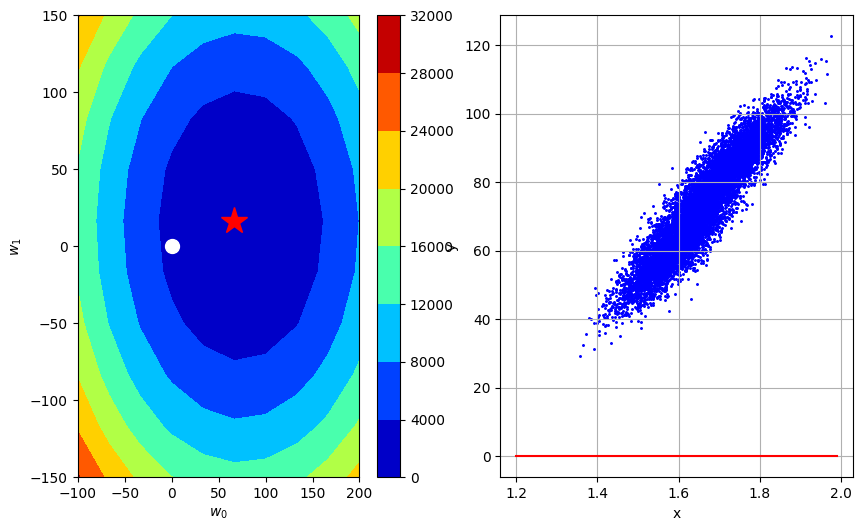

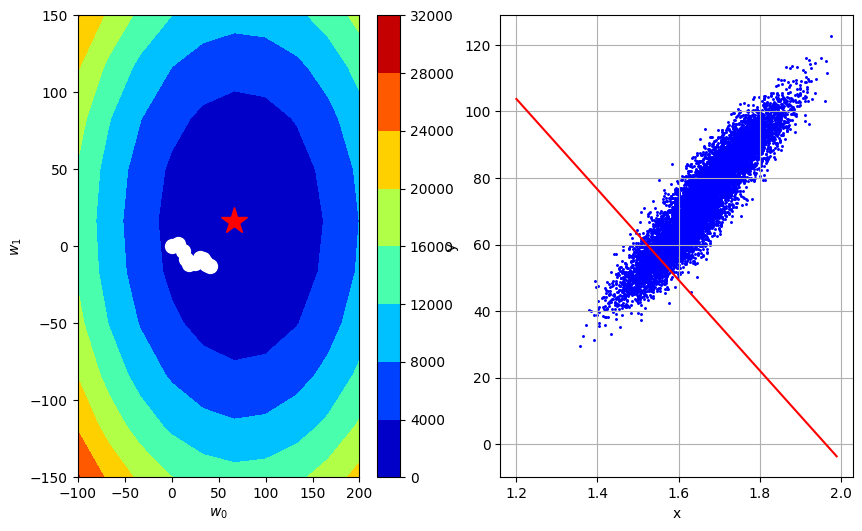

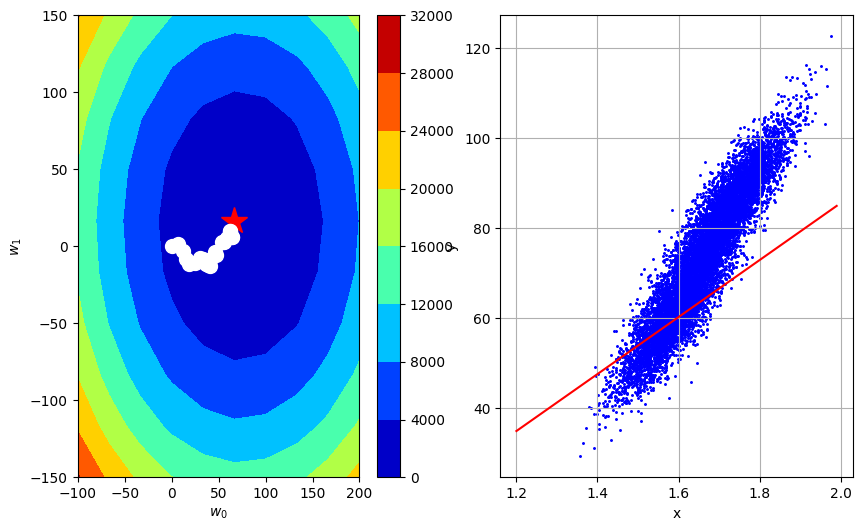

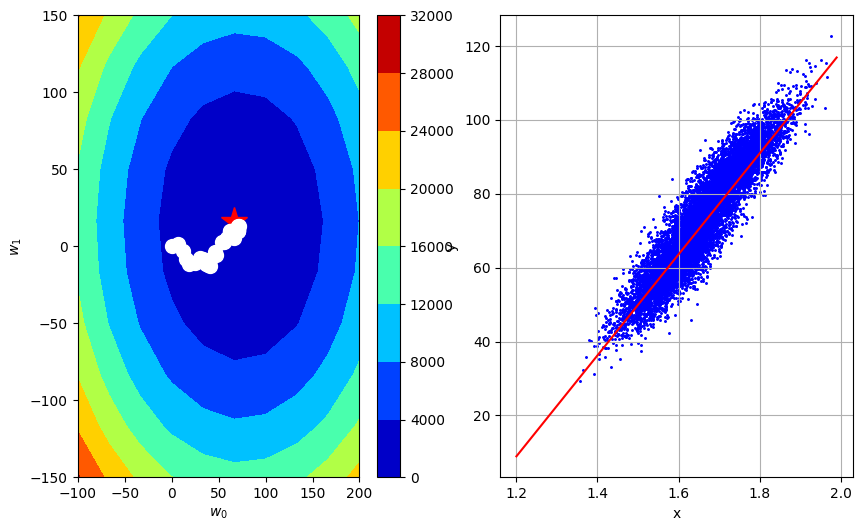

In [39]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

# 5. Effect of Outliers and MAE Cost Function

In [47]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: reload the data by subsampling first, then by subsampling and adding outliers
height, weight, gender = load_data(sub_sample=True, add_outlier=True)
# ***************************************************

x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [48]:
y.shape, tx.shape

((202,), (202, 2))

In [49]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([100, 20])

# Start gradient descent.
start_time = datetime.datetime.now()

# ***************************************************
# INSERT YOUR CODE HERE
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
# ***************************************************

end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))


GD iter. 0/49: loss=442.3566317234336, w0=81.84746409844846, w1=13.724426406192348
GD iter. 1/49: loss=99.80906124847802, w0=76.40170332798299, w1=11.841754328050069
GD iter. 2/49: loss=68.97977990573207, w0=74.76797509684336, w1=11.276952704607389
GD iter. 3/49: loss=66.20514458488496, w0=74.27785662750146, w1=11.107512217574586
GD iter. 4/49: loss=65.95542740600872, w0=74.1308210866989, w1=11.056680071464747
GD iter. 5/49: loss=65.93295285990986, w0=74.08671042445813, w1=11.041430427631795
GD iter. 6/49: loss=65.93093015076096, w0=74.0734772257859, w1=11.03685553448191
GD iter. 7/49: loss=65.93074810693756, w0=74.06950726618423, w1=11.035483066536946
GD iter. 8/49: loss=65.93073172299347, w0=74.06831627830373, w1=11.035071326153455
GD iter. 9/49: loss=65.93073024843848, w0=74.06795898193957, w1=11.034947804038408
GD iter. 10/49: loss=65.93073011572854, w0=74.06785179303033, w1=11.034910747403893
GD iter. 11/49: loss=65.93073010378464, w0=74.06781963635756, w1=11.034899630413538
GD it

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

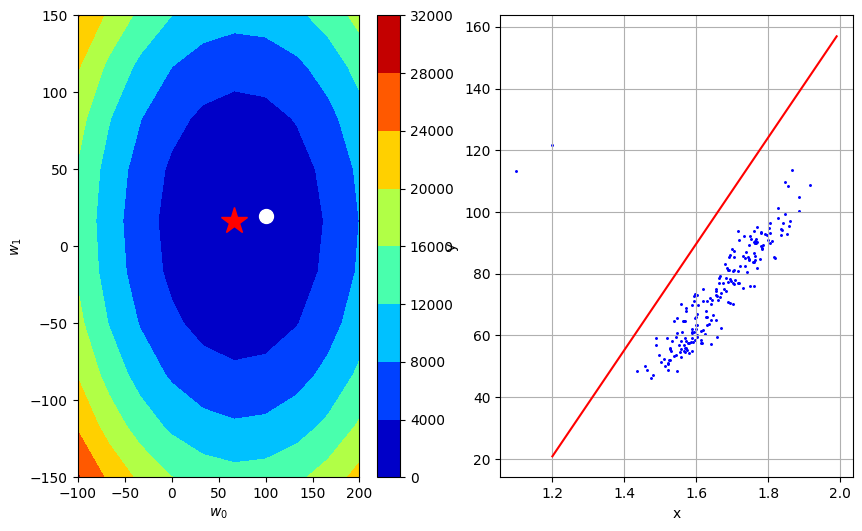

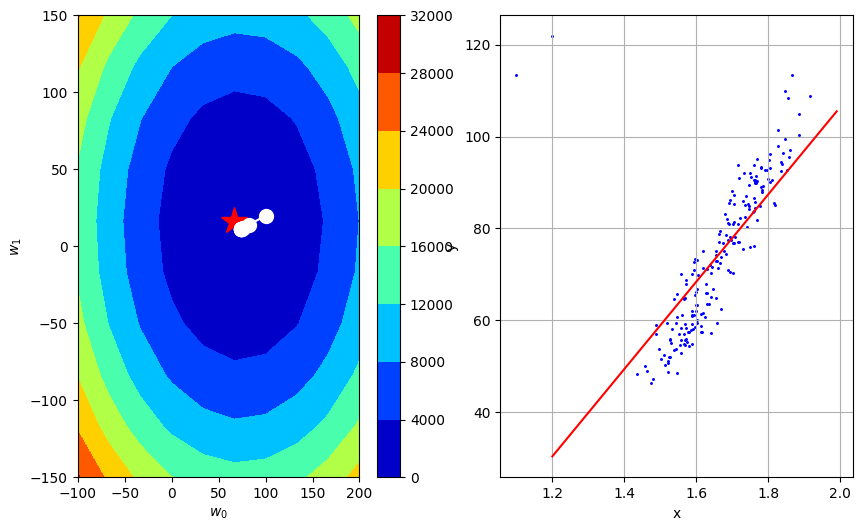

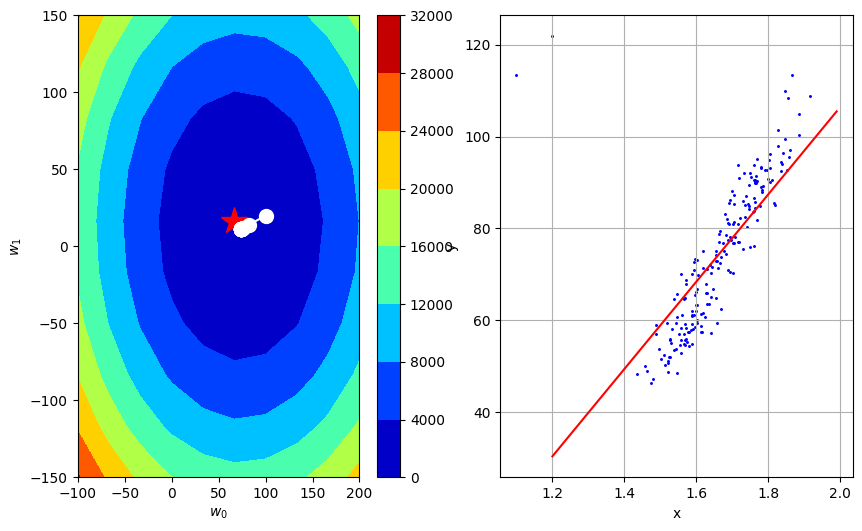

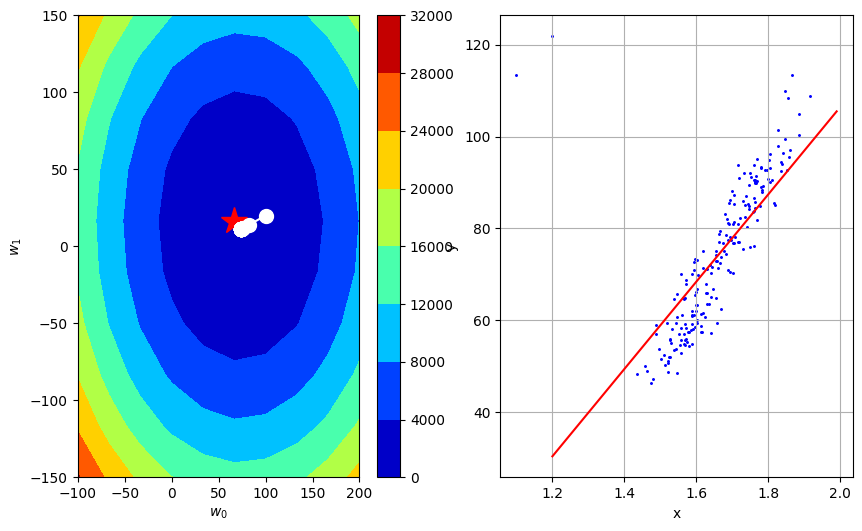

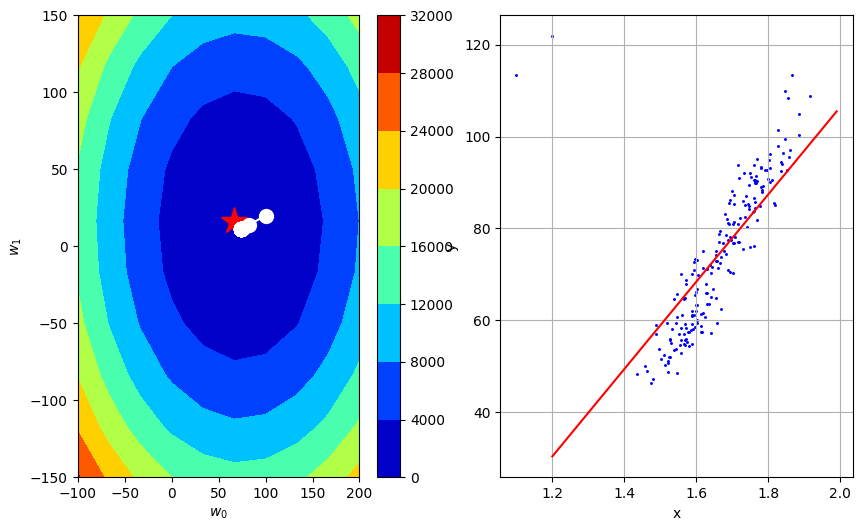

In [50]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 6. Subgradient descent

In [51]:
def compute_loss(y, tx, w):
    """Calculate the loss using MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    
    # ***************************************************
    total_error = 0
    for n in range(len(y)):
        total_error += np.abs(y[n] - tx[n].dot(w))
    return total_error
    # ***************************************************
    # raise NotImplementedError

In [74]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    N, d = tx.shape
    grad = np.zeros(d)
    for n in range(N):
        q = y[n] - tx[n].dot(w)
        if q < 0:
            grad += tx[n]
        elif q > 0:
            grad -= tx[n]
        else:
            # no changes (g+=0)
            print("---------------------------------")
            print("non differentiable point detected")
            print("---------------------------------")

    return grad/N
    # ***************************************************

In [75]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        gradient = compute_subgradient_mae(y, tx, w)
        loss = compute_loss(y, tx, w)
        # ***************************************************
        # INSERT YOUR CODE HERE
        w = w - gamma*gradient
        # ***************************************************

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [79]:
height, weight, gender = load_data(sub_sample=True, add_outlier=True)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [80]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([100, 20])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=5659.841705915739, w0=99.31386138613861, w1=19.93917382797546
SubGD iter. 1/499: loss=5522.918597103989, w0=98.62772277227722, w1=19.87834765595092
SubGD iter. 2/499: loss=5385.995488292237, w0=97.94158415841584, w1=19.817521483926377
SubGD iter. 3/499: loss=5249.072379480483, w0=97.25544554455445, w1=19.756695311901836
SubGD iter. 4/499: loss=5112.149270668729, w0=96.56930693069306, w1=19.695869139877296
SubGD iter. 5/499: loss=4975.226161856979, w0=95.88316831683167, w1=19.635042967852755
SubGD iter. 6/499: loss=4838.303053045228, w0=95.19702970297028, w1=19.574216795828214
SubGD iter. 7/499: loss=4701.379944233474, w0=94.5108910891089, w1=19.513390623803673
SubGD iter. 8/499: loss=4564.456835421719, w0=93.82475247524751, w1=19.452564451779132
SubGD iter. 9/499: loss=4427.5337266099705, w0=93.13861386138612, w1=19.39173827975459
SubGD iter. 10/499: loss=4290.610617798218, w0=92.45247524752473, w1=19.33091210773005
SubGD iter. 11/499: loss=4153.68750898647, w0=

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

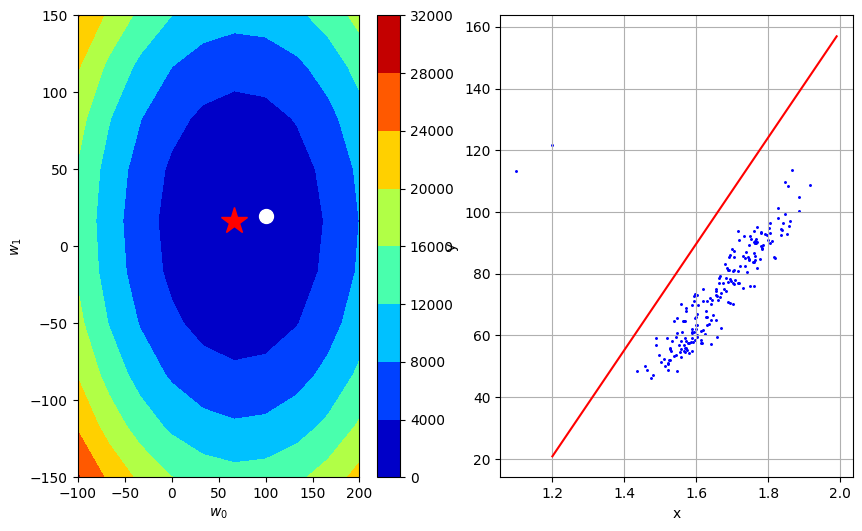

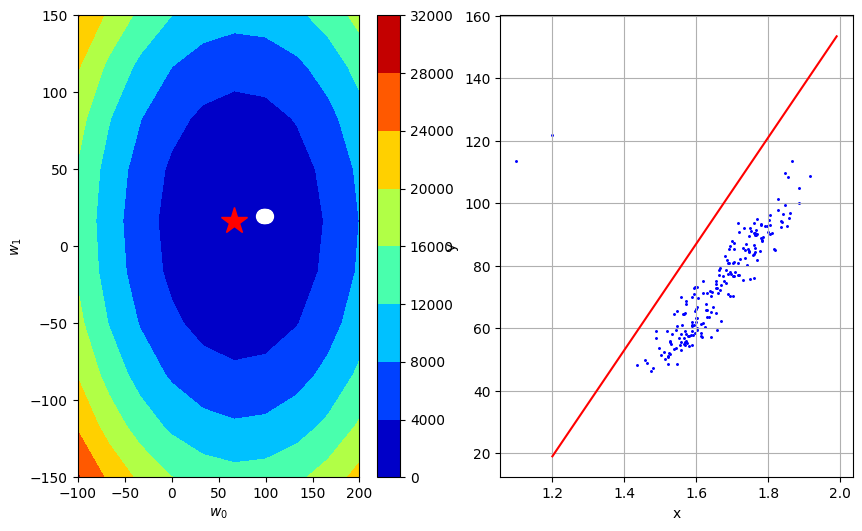

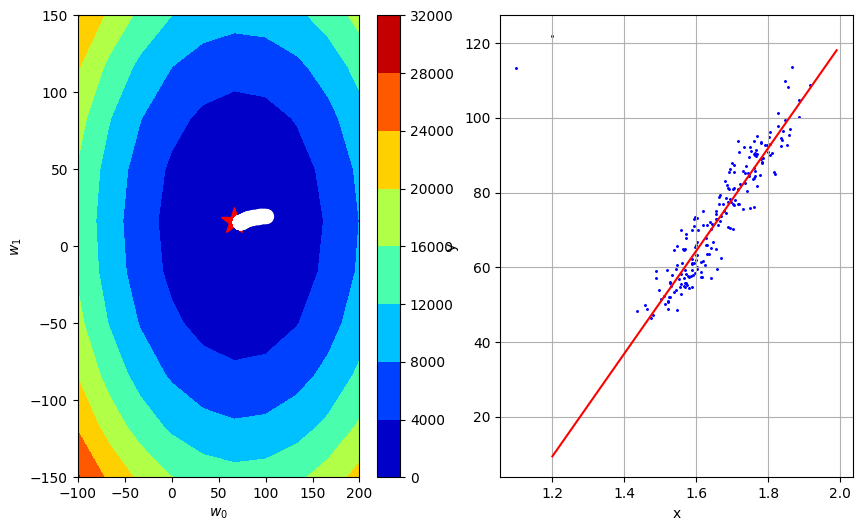

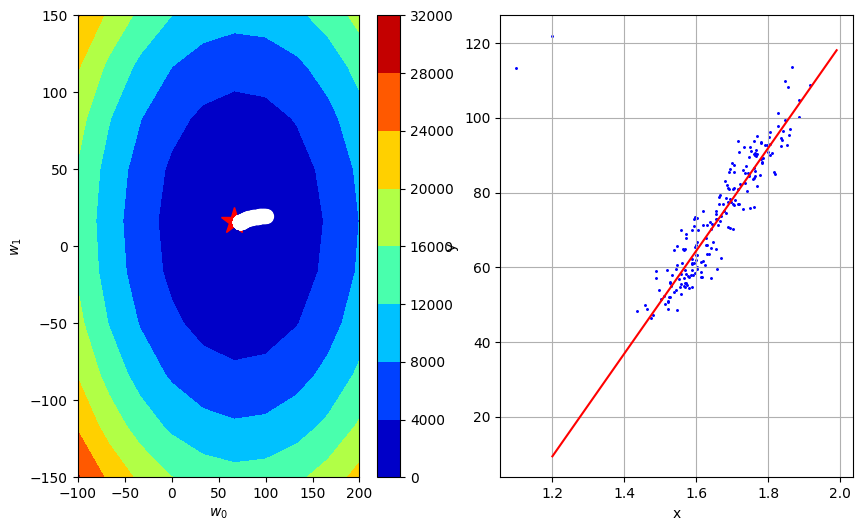

In [81]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [82]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size):
            stoch_gradient = compute_subgradient_mae(minibatch_y, minibatch_tx, w)
            w = w - gamma*stoch_gradient
            loss = compute_loss(y, tx, w)
            # Store values
            ws.append(w)
            losses.append(loss)
        # ***************************************************

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [85]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([100, 20])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=5739.233942552159, w0=100.7, w1=16.626856322410323
SubSGD iter. 1/499: loss=5615.378690604342, w0=100.0, w1=17.466883893870133
SubSGD iter. 2/499: loss=5705.35246398099, w0=100.7, w1=14.696584196981144
SubSGD iter. 3/499: loss=5562.010806059209, w0=100.0, w1=14.426445746691474
SubSGD iter. 4/499: loss=5412.651135500845, w0=99.3, w1=13.813453249507914
SubSGD iter. 5/499: loss=5270.029432236764, w0=98.6, w1=13.584331557221155
SubSGD iter. 6/499: loss=5132.847941121381, w0=97.89999999999999, w1=13.665145862709867
SubSGD iter. 7/499: loss=4991.3375943591345, w0=97.19999999999999, w1=13.49933960314237
SubSGD iter. 8/499: loss=4859.330138158474, w0=96.49999999999999, w1=13.87492544142894
SubSGD iter. 9/499: loss=4711.461335298038, w0=95.79999999999998, w1=13.346869625918291
SubSGD iter. 10/499: loss=4582.070057199045, w0=95.09999999999998, w1=13.87150255063003
SubSGD iter. 11/499: loss=4430.581538766484, w0=94.39999999999998, w1=13.13722680713823
SubSGD iter. 12/499:

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

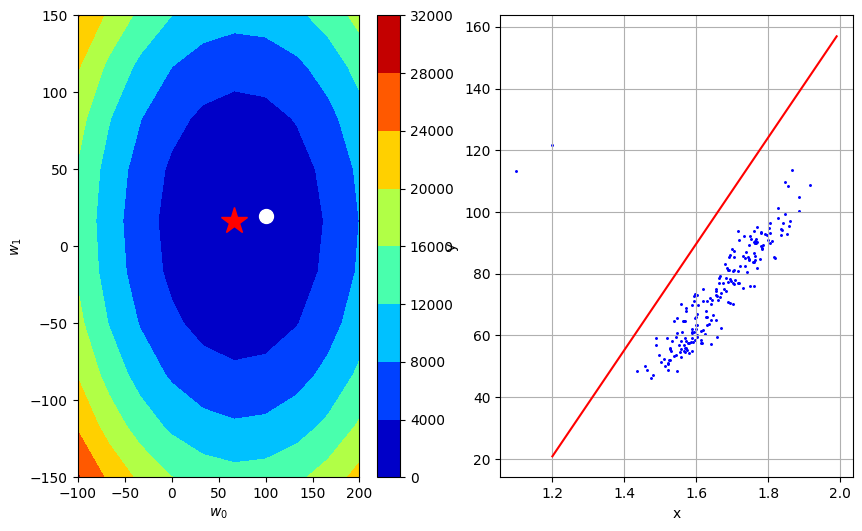

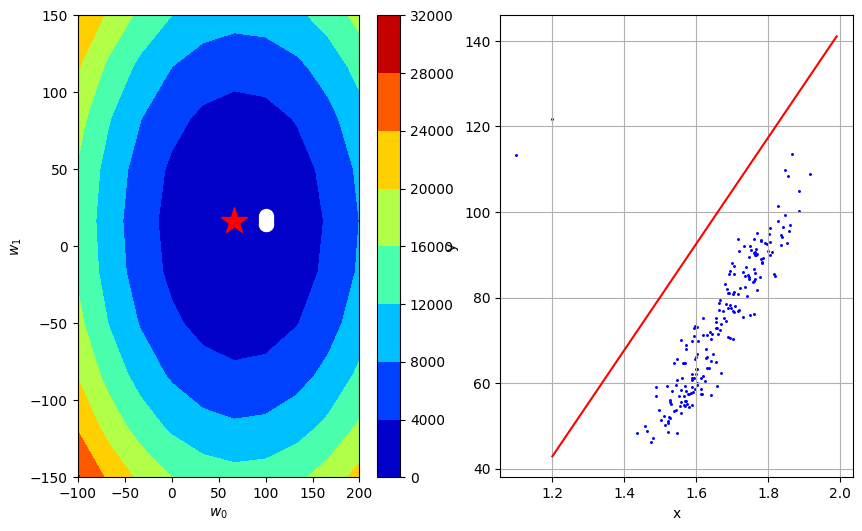

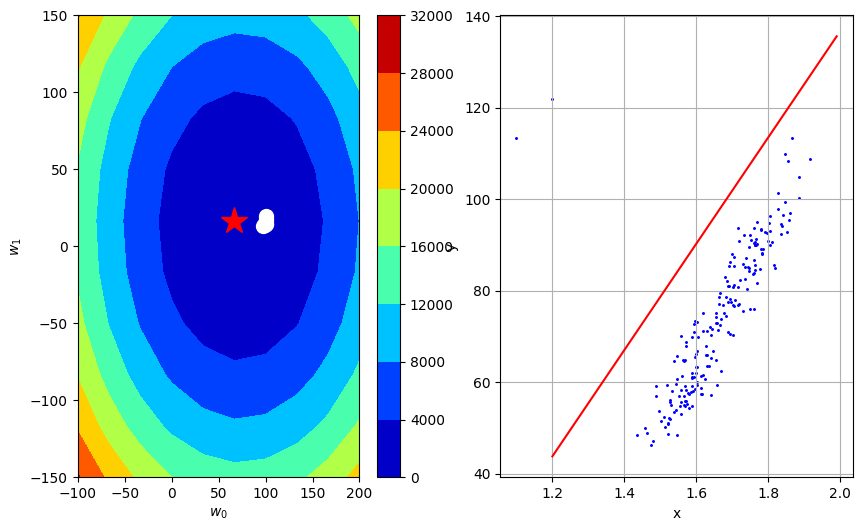

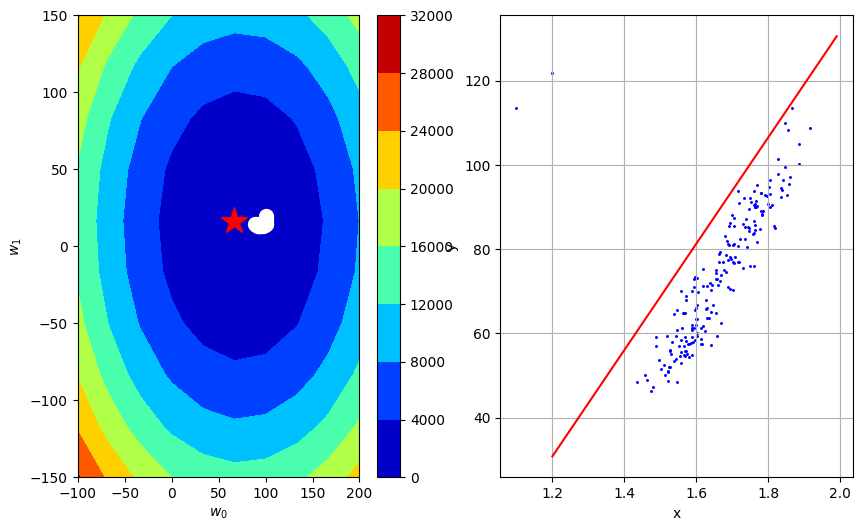

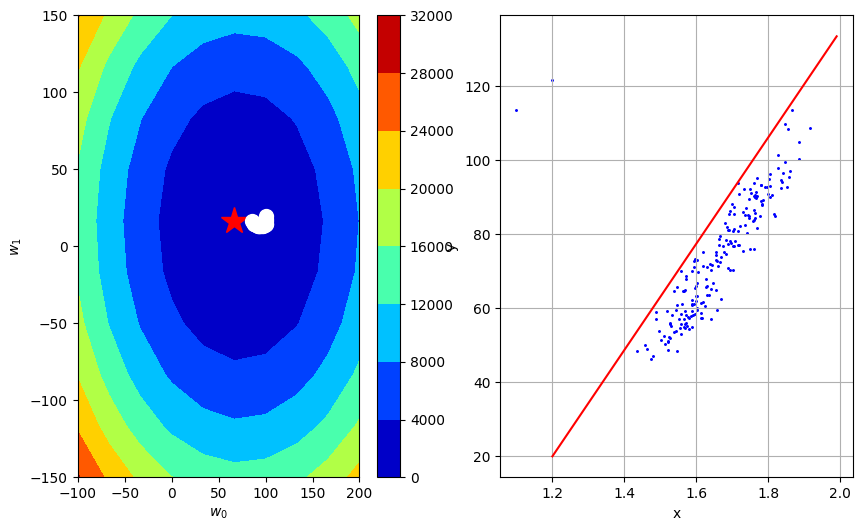

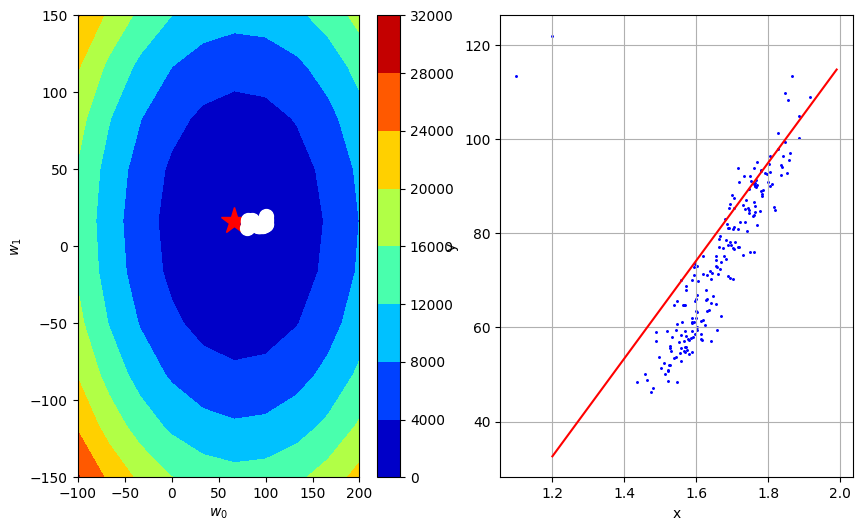

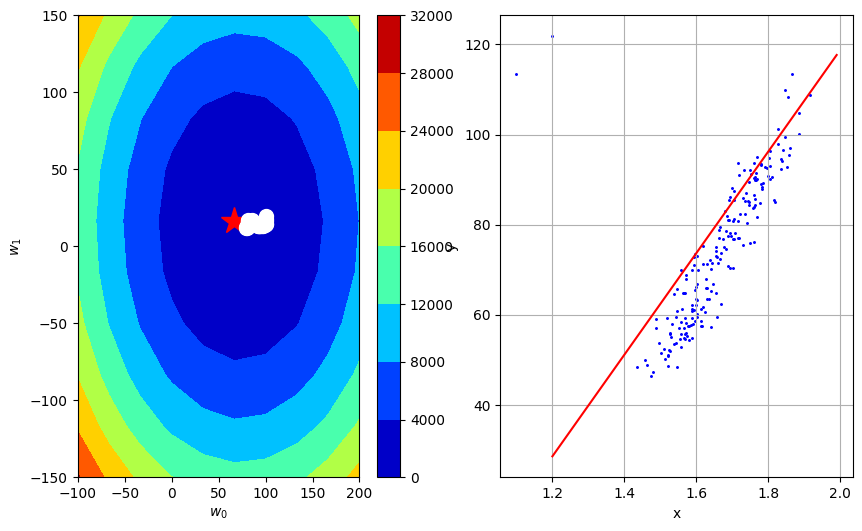

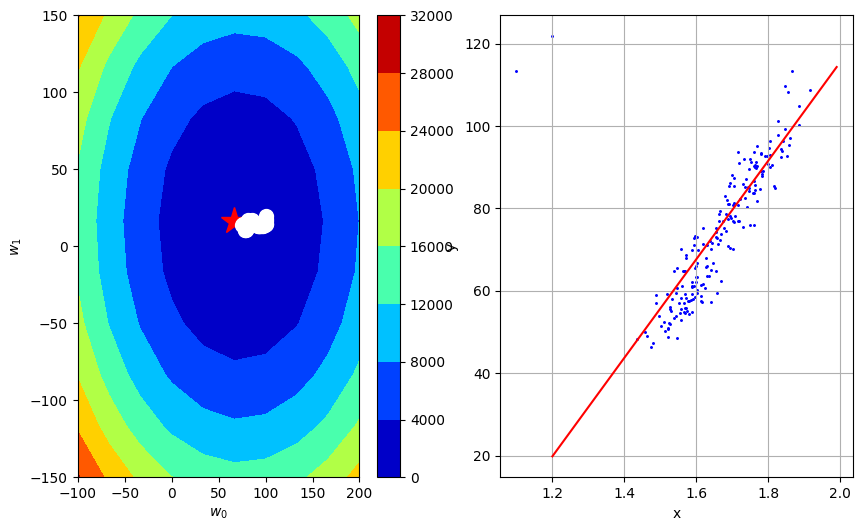

In [86]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))